In [1]:
import pandas as pd
df = pd.read_csv('data/VN_House_price_Clean2.csv')

In [2]:
df.head()

,Address,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price,City,District
0,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,4.00,3.5,2.0,2,3,Have certificate,Full,5.35,Hồ Chí Minh,Gò Vấp
1,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,4.00,5.0,2.0,4,4,Have certificate,Full,6.90,Hồ Chí Minh,Gò Vấp
2,"Đường Phạm Văn Chiêu, Phường 14, Gò Vấp, Hồ Ch...",30.0,3.85,5.0,2.0,2,2,Have certificate,Full,3.79,Hồ Chí Minh,Gò Vấp
3,"Đường Quang Trung, Phường 12, Gò Vấp, Hồ Chí Minh",46.0,4.60,6.0,4.0,4,5,Have certificate,Full,7.99,Hồ Chí Minh,Gò Vấp
4,"Đường Ngô Tất Tố, Phường 22, Bình Thạnh, Hồ Ch...",60.0,3.50,5.0,2.0,6,5,Have certificate,Full,5.60,Hồ Chí Minh,Bình Thạnh


In [3]:
df.columns

Index(['Address', 'Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms',
       'Bathrooms', 'Legal status', 'Furniture state', 'Price', 'City',
       'District'],
      dtype='object')

XGBoost:
  RMSE: 1.324 tỷ VND
  MAE: 0.986 tỷ VND
  R²: 0.6472


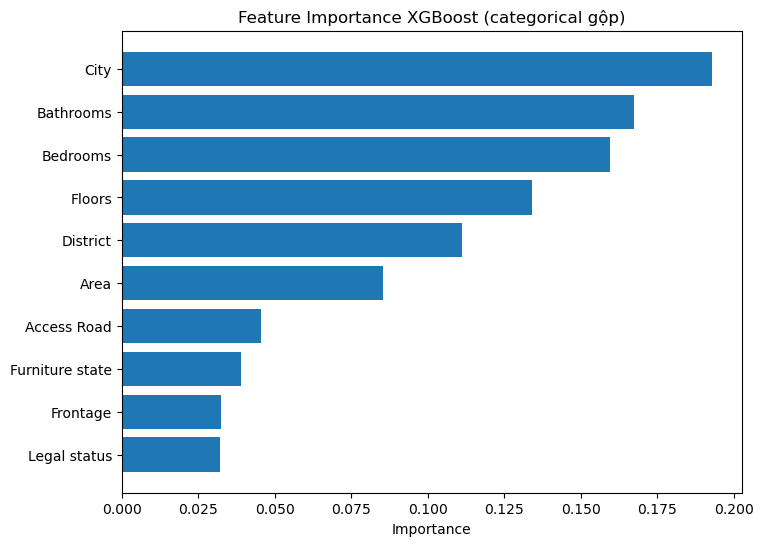

In [34]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Feature & Target
# -----------------------------
num_features = [	'Area',	'Access Road',	'Floors',	'Bedrooms',	'Bathrooms','Frontage']
cat_features = ['City', 'District','Legal status', 'Furniture state']
feature_cols = num_features + cat_features
target = "Price"

X = df[feature_cols].copy()
y = df[target]

# -----------------------------
# 2. LabelEncode categorical
# -----------------------------
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# -----------------------------
# 3. Scale numeric
# -----------------------------
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

# -----------------------------
# 4. Train/Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# 5. Train XGBoost
# -----------------------------
reg = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=42)
reg.fit(X_train, y_train)

# -----------------------------
# 6. Evaluate
# -----------------------------
y_pred = reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"XGBoost:")
print(f"  RMSE: {rmse:.3f} tỷ VND")          # Sai số bình phương trung bình gốc
print(f"  MAE: {mae:.3f} tỷ VND")             # ← In MAE ra đây
print(f"  R²: {r2:.4f}")

# -----------------------------
# 7. Feature Importance
# -----------------------------
importances = reg.feature_importances_

feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})

# Sắp xếp theo Importance giảm dần
feat_imp = feat_imp.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance XGBoost (categorical gộp)")
plt.show()


In [20]:
import joblib
import os
# Tạo thư mục 'model' nếu chưa tồn tại
os.makedirs('model', exist_ok=True)
# 1. Lưu model XGBoost
joblib.dump(reg, 'model/xgb_price_model.pkl')

# 2. Lưu scaler numeric
joblib.dump(scaler, 'model/scaler_numeric.pkl')

# 3. Lưu LabelEncoders cho categorical features
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    le.fit(df[col])  # fit trên toàn bộ dataset gốc
    label_encoders[col] = le

joblib.dump(label_encoders, 'model/label_encoders.pkl')


['model/label_encoders.pkl']

In [ ]:
import pandas as pd
import joblib

# Load các thành phần
reg = joblib.load('model/xgb_price_model.pkl')
scaler = joblib.load('model/scaler_numeric.pkl')
label_encoders = joblib.load('model/label_encoders.pkl')

# Định nghĩa đúng thứ tự features như lúc train
num_features = ['Area', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Frontage']
cat_features = ['City', 'District', 'Legal status', 'Furniture state']
feature_cols = num_features + cat_features  # Thứ tự đúng: Area -> Access Road -> ... -> Frontage -> categorical

# Tạo dữ liệu input
input_raw = {
    'Area': 80,
    'Frontage': 5,
    'Access Road': 5,
    'Floors': 3,
    'Bedrooms': 3,
    'Bathrooms': 2,
    'City': 'Hồ Chí Minh',
    'District': 'Bình Thạnh',
    'Legal status': 'Have certificate',
    'Furniture state': 'Full',
}

# Tạo DataFrame và sắp xếp lại đúng thứ tự cột
input_df = pd.DataFrame([input_raw])
input_df = input_df[feature_cols]  

# Encode categorical
for col in cat_features:
    input_df[col] = label_encoders[col].transform(input_df[col])

# Scale numeric
input_df[num_features] = scaler.transform(input_df[num_features])

# Dự đoán
price_pred = reg.predict(input_df)[0]
print(f"Predicted Price: {round(price_pred, 2)} tỷ VND")

Predicted Price: 8.449999809265137 tỷ VND


XGBoost Cải thiện (không early stopping):
  RMSE: 0.101 tỷ
  R²: 0.9980


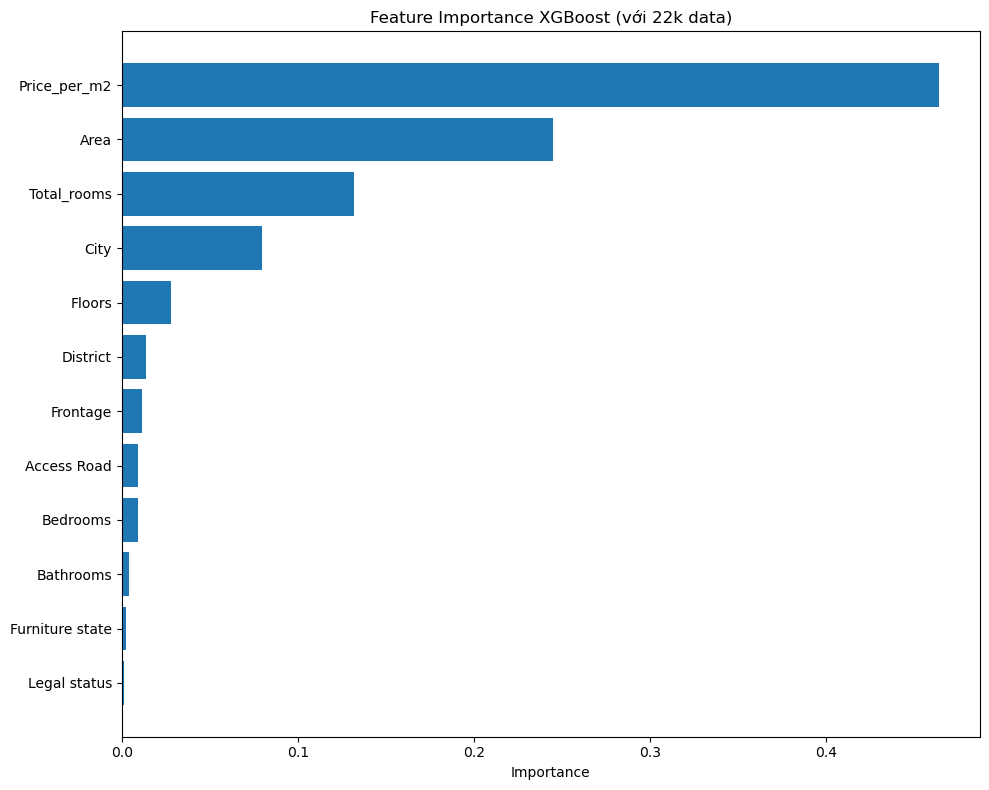

In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/VN_House_price_Clean2.csv')  # Đường dẫn file của bạn

# -----------------------------
# 1. Feature & Target (thêm feature engineering nhẹ)
# -----------------------------
num_features = ['Area', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Frontage']
cat_features = ['City', 'District', 'Legal status', 'Furniture state']

# Thêm feature mới (giúp tăng R²)
df['Price_per_m2'] = df['Price'] / df['Area']  # Giá/m² - feature mạnh
df['Total_rooms'] = df['Bedrooms'] + df['Bathrooms']

num_features += ['Price_per_m2', 'Total_rooms']  # Thêm vào numerical

feature_cols = num_features + cat_features
target = "Price"

X = df[feature_cols].copy()
y = df[target]

# -----------------------------
# 2. Encoding categorical tốt hơn (vẫn LabelEncoder, nhưng ổn với 22k data)
# -----------------------------
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))  # astype(str) phòng NaN

# -----------------------------
# 3. Scale numeric
# -----------------------------
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

# -----------------------------
# 4. Split (tăng test_size nếu muốn đánh giá chính xác hơn)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# 5. XGBoost mạnh hơn (tăng n_estimators, thêm early stopping)
# -----------------------------
reg = xgb.XGBRegressor(
    n_estimators=2000,      # Tăng mạnh số cây (an toàn với data lớn)
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    tree_method='hist'      # Vẫn giữ để nhanh
)

# Huấn luyện KHÔNG dùng early_stopping
reg.fit(X_train, y_train)   # Chỉ dòng này thôi

# Evaluate
y_pred = reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"XGBoost Cải thiện (không early stopping):\n  RMSE: {rmse:.3f} tỷ\n  R²: {r2:.4f}")

# -----------------------------
# 7. Feature Importance
# -----------------------------
importances = reg.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10,8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance XGBoost (với 22k data)")
plt.tight_layout()
plt.show()

Random Forest:
  RMSE: 1.405 tỷ VND
  MAE: 1.041 tỷ VND
  R²: 0.6024


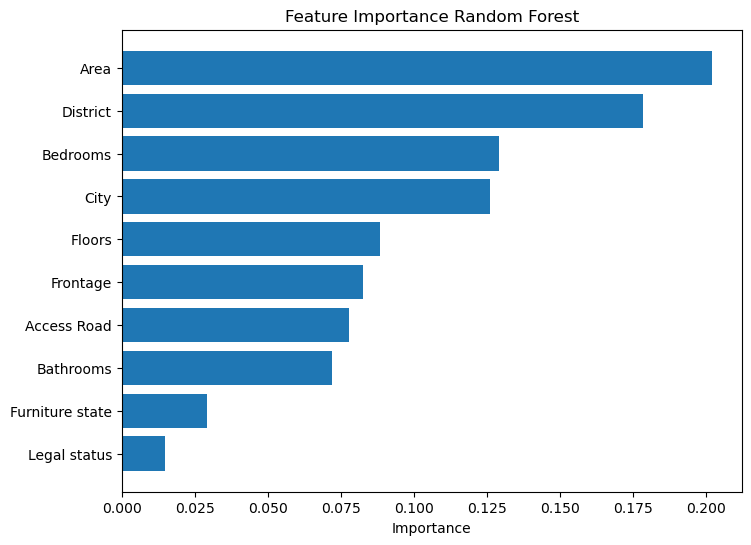

In [33]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor  # ← Import này
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# (Giả sử df đã đọc: df = pd.read_csv('data/VN_House_price_Clean2.csv'))

# 1. Feature & Target (giống XGBoost)
num_features = ['Area', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Frontage']
cat_features = ['City', 'District', 'Legal status', 'Furniture state']
feature_cols = num_features + cat_features
target = "Price"

X = df[feature_cols].copy()
y = df[target]

# 2. LabelEncode categorical (giống)
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 3. Scale numeric (RF không cần, nhưng giữ để giống)
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

# 4. Split (giống)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Random Forest (tương tự tham số XGBoost để công bằng)
rf = RandomForestRegressor(
   n_estimators=1000,
    max_depth=None,
    max_features=0.8,      # Giống colsample_bytree=0.8
    max_samples=0.8,       # Giống subsample=0.8
    random_state=42,
    n_jobs=-1          
)
rf.fit(X_train, y_train)

# 6. Evaluate + MAE
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print(f"  RMSE: {rmse_rf:.3f} tỷ VND")
print(f"  MAE: {mae_rf:.3f} tỷ VND")
print(f"  R²: {r2_rf:.4f}")

# 7. Feature Importance (giống XGBoost)
importances_rf = rf.feature_importances_
feat_imp_rf = pd.DataFrame({'Feature': feature_cols, 'Importance': importances_rf})
feat_imp_rf = feat_imp_rf.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feat_imp_rf['Feature'], feat_imp_rf['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance Random Forest")
plt.show()